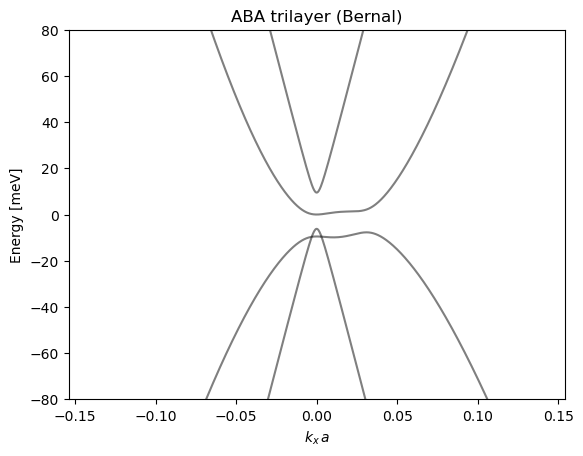

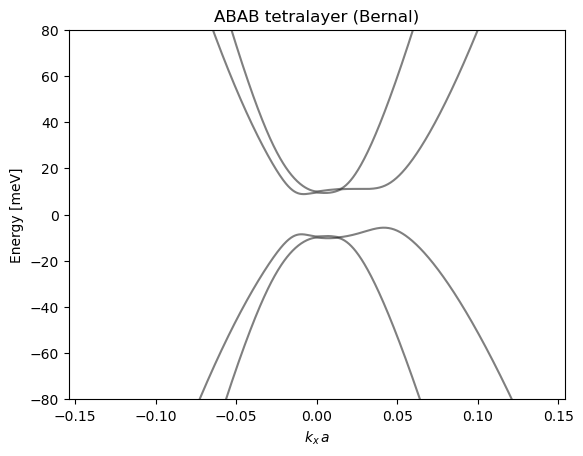

In [13]:
import jax
import jax.numpy as jnp
import contimod_graphene as cm_graphene
import matplotlib.pyplot as plt

graphene_params_ABA = { 
    "gamma0": 3100,  
    "gamma1": 370,  
    "gamma2": -19, 
    "gamma3": 315, 
    "gamma4": 140,  
    "gamma5": 20, 
    "U": 0.0, 
    "Delta": 18.5, 
    "delta": 3.8,        
}

# ----------------------------------------------------------------------
# Common k-path
# ----------------------------------------------------------------------
k_lin = 0.28 * jnp.linspace(-0.5, 0.5, 800)
ks_path = jnp.array([[kx, 0.0] for kx in k_lin])  # shape (Nk, 2)

# ----------------------------------------------------------------------
# ABA trilayer (Bernal, N_layers = 3)
# ----------------------------------------------------------------------
params_aba = dict(graphene_params_ABA)  # copy so we don't mutate the global
params_aba["U"] = 0.0
# params_aba["gamma2"] = 0.0
# params_aba["gamma5"] = 0.0

h_aba = cm_graphene.bernal.get_hamiltonian(N_layers=3, params=params_aba)

# Evaluate H(k) along the path and diagonalize
hs_path_aba = jax.vmap(h_aba, in_axes=(0, 0))(*ks_path.T)      # list of 6x6 matrices
bands_path_aba = jnp.linalg.eigvalsh(hs_path_aba)               # shape (Nk, 6)

plt.figure()
for band in bands_path_aba.T:
    plt.plot(k_lin, band, color="black", linewidth=1.5, alpha=0.5)

plt.xlabel(r"$k_x \, a$")
plt.ylabel(r"Energy [meV]")
plt.ylim(-80, 80)
plt.title("ABA trilayer (Bernal)")
plt.show()

# ----------------------------------------------------------------------
# ABAB tetralayer (Bernal, N_layers = 4)
# ----------------------------------------------------------------------
params_abab = dict(graphene_params_ABA)
params_abab["U"] = 0.0
# params_abab["gamma2"] = 0.0
# params_abab["gamma5"] = 0.0

h_abab = cm_graphene.bernal.get_hamiltonian(N_layers=4, params=params_abab)

hs_path_abab = jax.vmap(h_abab, in_axes=(0, 0))(*ks_path.T)    # list of 8x8 matrices
bands_path_abab = jnp.linalg.eigvalsh(hs_path_abab)             # shape (Nk, 8)

plt.figure()
for band in bands_path_abab.T:
    plt.plot(k_lin, band, color="black", linewidth=1.5, alpha=0.5)

plt.xlabel(r"$k_x \, a$")
plt.ylabel(r"Energy [meV]")
plt.ylim(-80, 80)
plt.title("ABAB tetralayer (Bernal)")
plt.show()
